In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dateutil import parser
%matplotlib inline 

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier   # ✅ FIXED
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV
import pickle
from lightgbm import LGBMClassifier 

print('Library Loaded')

Library Loaded


In [9]:
import pandas as pd

data = pd.read_csv("D:/University/BSIT 6th Semester books and assignments/Data Science/Project/heart.csv")

data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [11]:
df = data.copy()
df.shape

(303, 14)

In [12]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [13]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [14]:
cols = df.columns 
cols

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [17]:
print("# rows in dataset (0)".format(len(df)))
print("----------------------------------------------")


for col in cols:
    print("# rows in {} with Zero value: {}".format(col, len(df[df[col] == 0])))

# rows in dataset (0)
----------------------------------------------
# rows in age with Zero value: 0
# rows in sex with Zero value: 96
# rows in cp with Zero value: 143
# rows in trestbps with Zero value: 0
# rows in chol with Zero value: 0
# rows in fbs with Zero value: 258
# rows in restecg with Zero value: 147
# rows in thalach with Zero value: 0
# rows in exang with Zero value: 204
# rows in oldpeak with Zero value: 99
# rows in slope with Zero value: 21
# rows in ca with Zero value: 175
# rows in thal with Zero value: 2
# rows in target with Zero value: 138


In [18]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

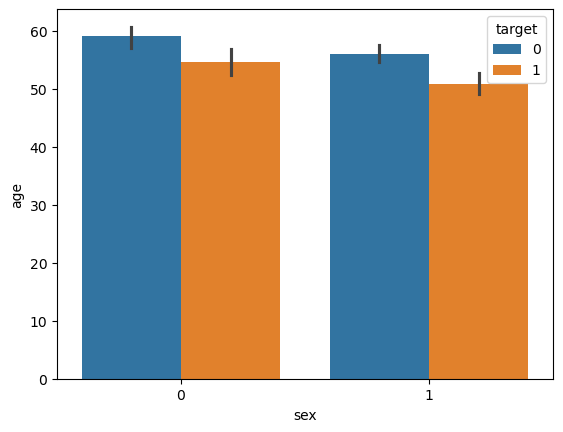

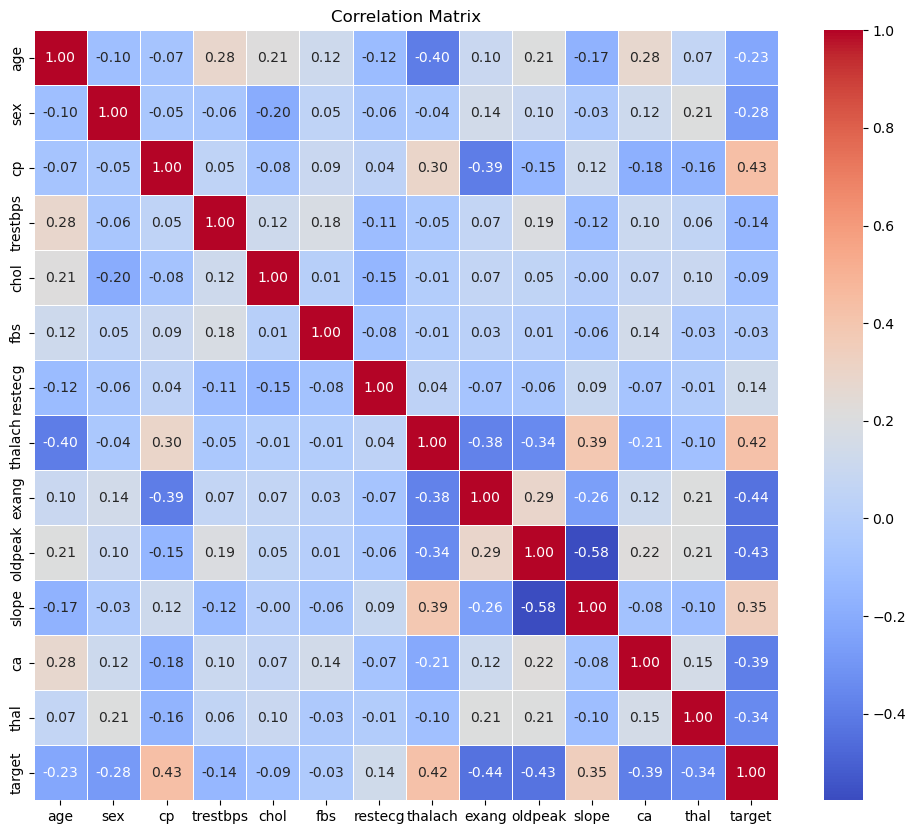

In [21]:
plt.figure(figsize=(12,10))

sns.heatmap(corrmat, 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f',
            linewidths=0.5)

plt.title("Correlation Matrix")
plt.show()

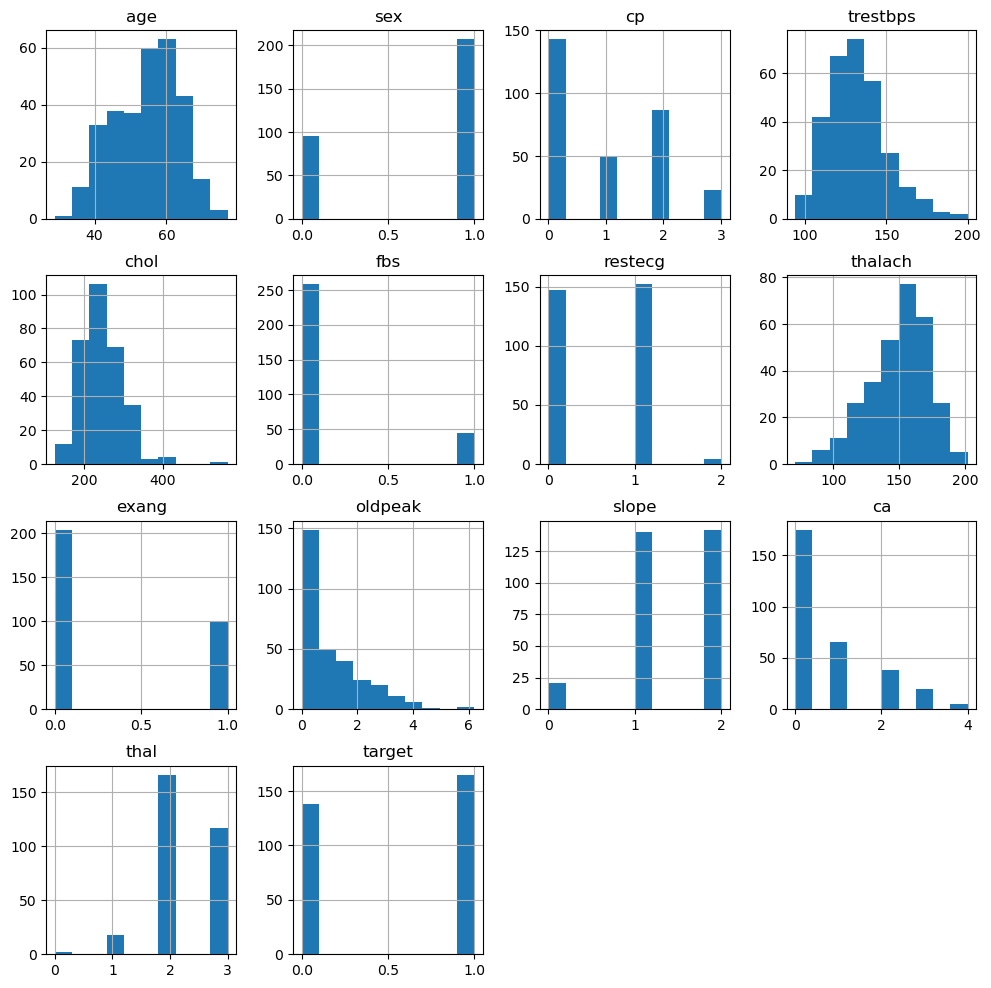

In [22]:
df.hist(figsize=(12,12))
plt.show()

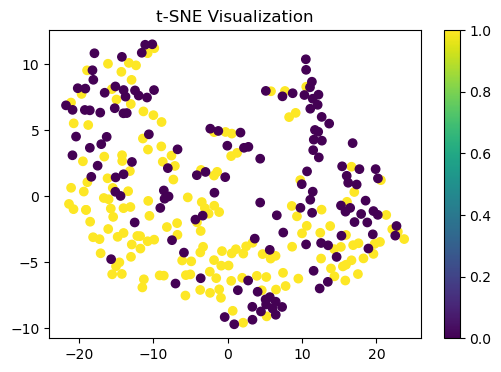

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(df_tsne[:,0], df_tsne[:,1], c=df['target'], cmap='viridis')
plt.colorbar()
plt.title("t-SNE Visualization")
plt.show()

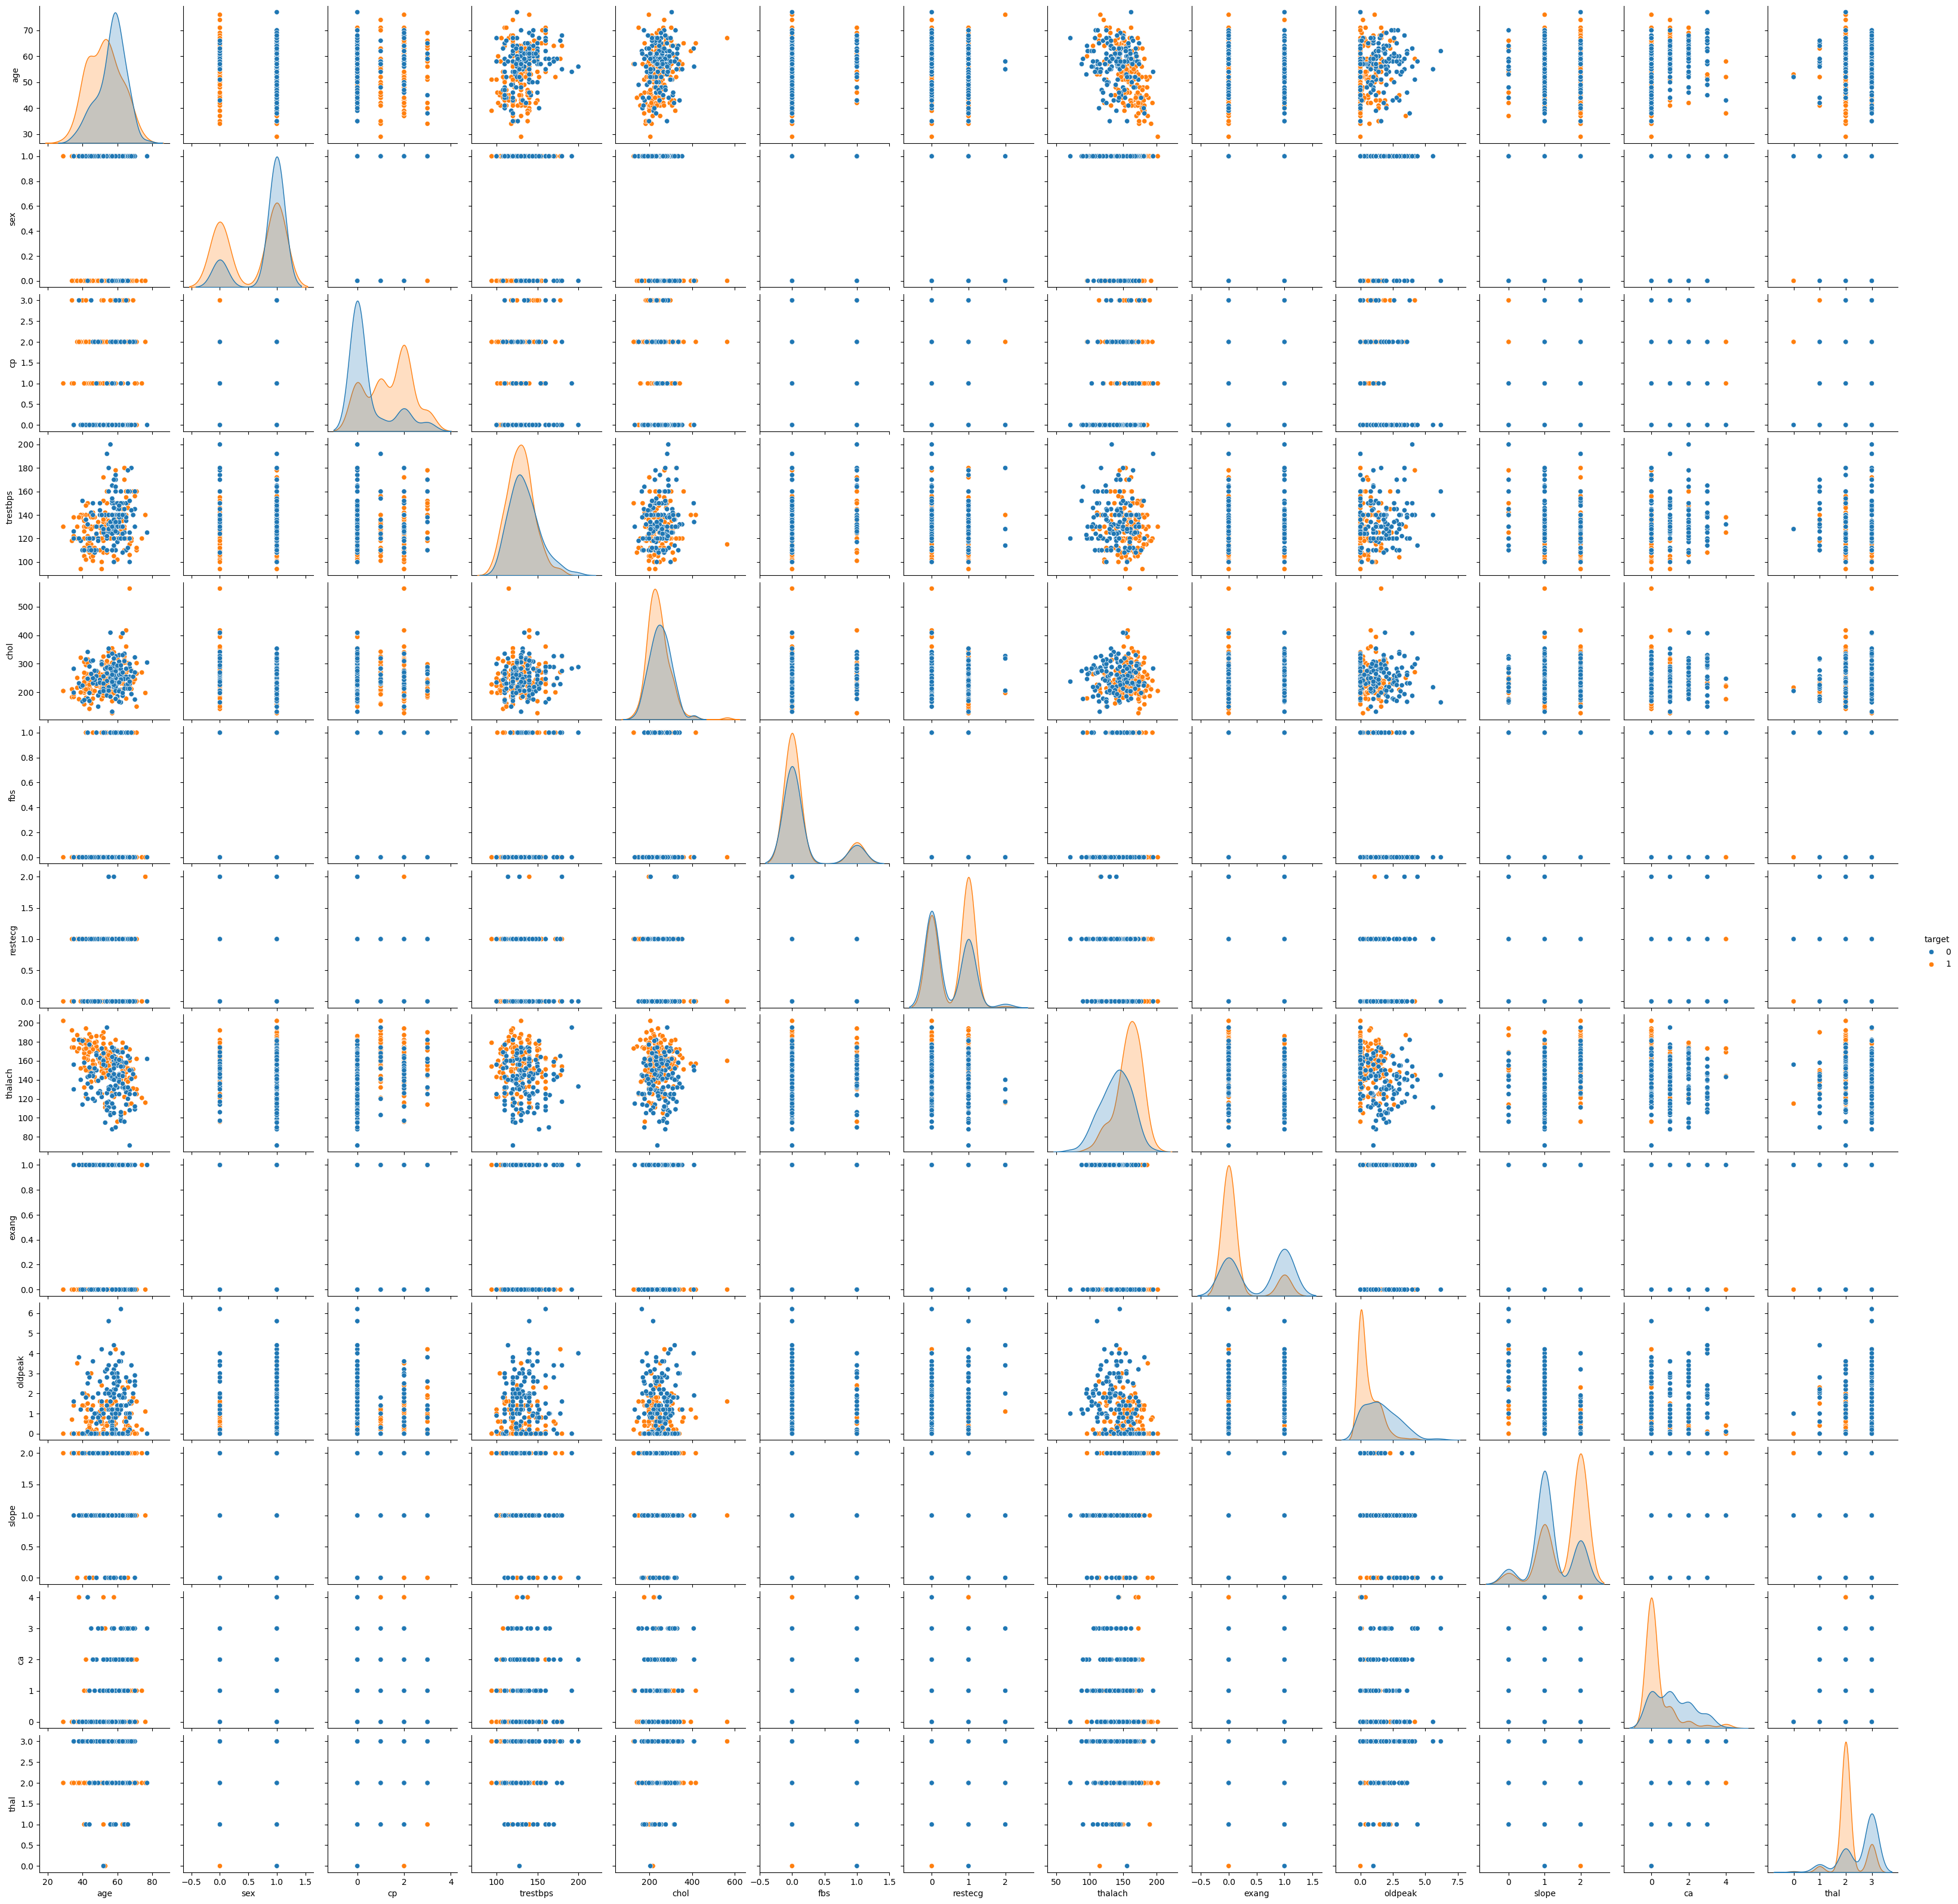

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

df_clean = df.replace([np.inf, -np.inf], np.nan).dropna()

df_clean['target'] = df_clean['target'].astype(int)

sns.pairplot(df_clean, hue='target')
plt.show()

In [80]:
X=df.drop('target',axis=1)
from sklearn.manifold import TSNE
import time
time_start = time.time()

df_tsne = TSNE(random_state=10).fit_transform(X)

print(f"t-SNE done! Time elapsed: {time.time() - time_start:.2f} seconds")

t-SNE done! Time elapsed: 3.06 seconds


In [81]:
df_tsne

array([[-1.82014132e+00,  1.58177984e+00],
       [-1.82219219e+00, -4.82766819e+00],
       [-1.39777927e+01, -2.77075815e+00],
       [-3.68215561e+00, -7.08780003e+00],
       [ 2.04741497e+01, -3.44691300e+00],
       [-1.65684795e+01,  3.01851797e+00],
       [ 1.37831478e+01, -2.24299049e+00],
       [ 2.11029005e+00, -4.33168364e+00],
       [-1.41798153e+01,  3.12632775e+00],
       [-1.93214836e+01,  3.68620902e-01],
       [-2.54902267e+00, -1.30517566e+00],
       [ 7.79220581e+00, -6.79037905e+00],
       [ 4.70483494e+00, -4.37025070e+00],
       [-9.96980476e+00,  6.15890217e+00],
       [ 1.06366329e+01, -2.22769618e+00],
       [-1.05031900e+01, -1.47147894e+00],
       [ 1.95958118e+01, -4.35497904e+00],
       [-9.85143471e+00,  1.12334375e+01],
       [-3.29424715e+00, -3.81745267e+00],
       [-1.40414333e+00,  1.86464381e+00],
       [-3.47052670e+00, -4.26827610e-01],
       [-5.60509825e+00, -5.96475935e+00],
       [-6.10625839e+00, -4.85299826e+00],
       [ 1.

In [94]:
import matplotlib.patheffects as PathEffects
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def fashion_scatter(x, colors):
    num_classes = len(np.unique(colors))
    palette = np.array(sns.color_palette("deep", num_classes))

    f = plt.figure(figsize=(8, 8))
    ax = plt.subplot(aspect='equal')

    sc = ax.scatter(
        x[:, 0], x[:, 1],
        lw=0,
        s=40,
        c=palette[colors.astype(int)]
    )

    plt.xlim(-25, 25)
    plt.ylim(-25, 25)

    ax.axis('off')
    ax.axis('tight')

    txts = []

    for i in range(num_classes):
        xtext, ytext = np.median(x[colors == i, :], axis=0)

        txt = ax.text(xtext, ytext, str(i), fontsize=24)
        txt.set_path_effects([
            PathEffects.Stroke(linewidth=5, foreground='w'),
            PathEffects.Normal()
        ])

        txts.append(txt)

    plt.show()   # ✅ THIS IS THE FIX

    return f, ax, sc, txts

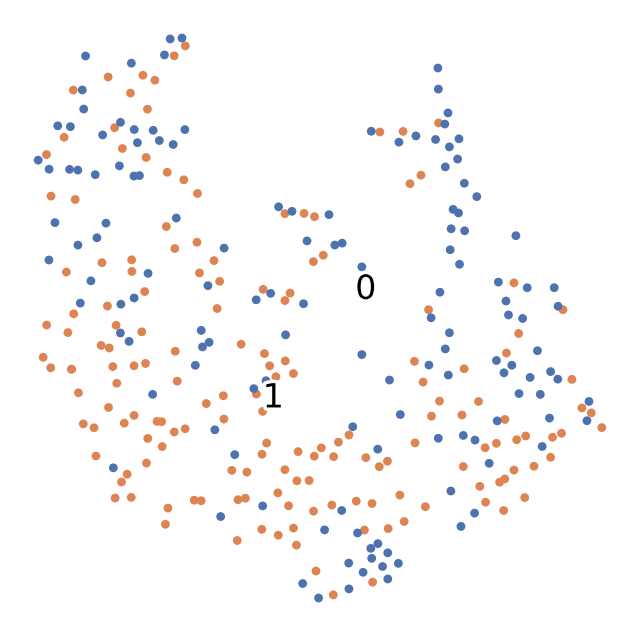

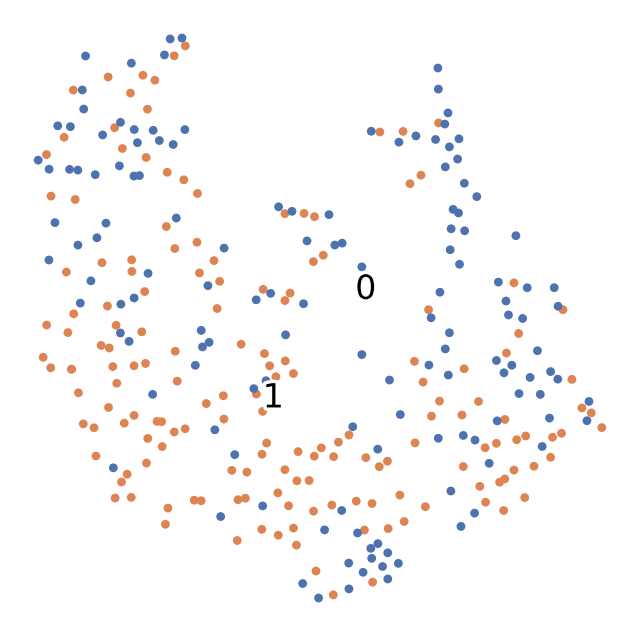

(<Figure size 800x800 with 1 Axes>,
 <Axes: >,
 [Text(3.84248685836792, 1.6458879709243774, '0'),
  Text(-3.6147189140319824, -2.468754529953003, '1')])

In [95]:
fashion_scatter(df_tsne, df.target)

In [98]:
df.target.value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [99]:
print("# rows in dataset {0}".format(len(df)))
print("#-----------------------------------------")

for col in cols:
    print("# rows in {1} with ZERO value: {0}".format(len(df.loc[df[col] == 0]),col))

# rows in dataset 303
#-----------------------------------------
# rows in age with ZERO value: 0
# rows in sex with ZERO value: 96
# rows in cp with ZERO value: 143
# rows in trestbps with ZERO value: 0
# rows in chol with ZERO value: 0
# rows in fbs with ZERO value: 258
# rows in restecg with ZERO value: 147
# rows in thalach with ZERO value: 0
# rows in exang with ZERO value: 204
# rows in oldpeak with ZERO value: 99
# rows in slope with ZERO value: 21
# rows in ca with ZERO value: 175
# rows in thal with ZERO value: 2
# rows in target with ZERO value: 138


In [100]:
X = df.drop('target', axis=1) #predictor feature columns
y = df.target

X_train , X_test , y_train , y_test = train_test_split(X, y, test_size = 0.10, random_state = 10)

print('Training Set :',len(X_train))
print('Test Set :',len(X_test))
print('Training Labels :',len(y_train))
print('Test Labels :',len(y_test))

Training Set : 272
Test Set : 31
Training Labels : 272
Test Labels : 31


In [101]:
from sklearn.impute import SimpleImputer

# impute missing values with mean
fill = SimpleImputer(missing_values=0, strategy="mean")

X = fill.fit_transform(X)
X_train = fill.fit_transform(X_train)
X_test = fill.fit_transform(X_test)

In [92]:
def FitModel(X_train,y_train,X_test,y_test,algo_name,algorithm,gridSearchParams,cv):
    np.random.seed(10)

    grid = GridSearchCV(
        estimator=algorithm,
        param_grid=gridSearchParams,
        cv=cv, scoring='accuracy', verbose=1, n_jobs=-1)


    grid_result = grid.fit(X_train, y_train)
    best_params = grid_result.best_params_ 
    pred = grid_result.predict(X_test)
    cm = confusion_matrix(y_test, pred)

    # metrics = grid_result.gr 
    print(pred)
    # pickle.dump(grid_result,open(algo_name, 'web'))

    print('Best Params :',best_params)
    print('Classification Report :',classification_report(y_test,pred))
    print('Accuracy Score :' + str(accuracy_score(y_test,pred)))
    print('Confusion Matrix : \n', cm)

In [102]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import numpy as np

penalty = ['l1', 'l2']
C = np.logspace(0, 4, 10)

hyperparameters = dict(C=C, penalty=penalty)

model = LogisticRegression(solver='liblinear')  # IMPORTANT for l1

FitModel(X_train, y_train, X_test, y_test,
         'LogisticRegression',
         model,
         hyperparameters,
         cv=5)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[0 0 0 1 0 1 1 0 1 0 1 0 0 1 0 1 0 0 1 0 0 1 1 1 0 0 0 0 1 0 1]
Best Params : {'C': np.float64(1.0), 'penalty': 'l1'}
Classification Report :               precision    recall  f1-score   support

           0       0.94      0.94      0.94        18
           1       0.92      0.92      0.92        13

    accuracy                           0.94        31
   macro avg       0.93      0.93      0.93        31
weighted avg       0.94      0.94      0.94        31

Accuracy Score :0.9354838709677419
Confusion Matrix : 
 [[17  1]
 [ 1 12]]


In [106]:
param = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': np.arange(0.01, 0.1, 0.03).tolist()
}

FitModel(X_train,y_train,X_test,y_test,'XGBoost',XGBClassifier(),param,cv=5)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 1 0 0 1 0 0 1 1 1 0 0 0 0 1 0 1]
Best Params : {'learning_rate': 0.04, 'max_depth': 3, 'n_estimators': 100}
Classification Report :               precision    recall  f1-score   support

           0       0.89      0.94      0.92        18
           1       0.92      0.85      0.88        13

    accuracy                           0.90        31
   macro avg       0.91      0.90      0.90        31
weighted avg       0.90      0.90      0.90        31

Accuracy Score :0.9032258064516129
Confusion Matrix : 
 [[17  1]
 [ 2 11]]


In [107]:
param ={
            'n_estimators': [100, 500, 1000, 1500, 2000],
            'max_depth' : [2,3,4,5,6,7],

          }

FitModel(X_train,y_train,X_test,y_test,'Random Forest',RandomForestClassifier(),param,cv=5)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[0 0 0 1 0 1 1 0 1 0 1 0 0 1 0 1 0 0 1 0 0 1 1 1 0 0 0 0 1 0 1]
Best Params : {'max_depth': 4, 'n_estimators': 500}
Classification Report :               precision    recall  f1-score   support

           0       0.94      0.94      0.94        18
           1       0.92      0.92      0.92        13

    accuracy                           0.94        31
   macro avg       0.93      0.93      0.93        31
weighted avg       0.94      0.94      0.94        31

Accuracy Score :0.9354838709677419
Confusion Matrix : 
 [[17  1]
 [ 1 12]]


In [108]:
param ={
            'C': [0.1, 1, 100, 1000],
            'gamma' : [0.0001, 0.001, 0.05, 0.1, 1, 3, 5],

          }

FitModel(X_train,y_train,X_test,y_test,'SVC',SVC(),param,cv=5)

Fitting 5 folds for each of 28 candidates, totalling 140 fits
[1 0 0 1 0 1 1 0 1 0 1 1 1 1 0 1 0 0 1 0 0 1 1 1 0 0 0 0 1 0 1]
Best Params : {'C': 1000, 'gamma': 0.0001}
Classification Report :               precision    recall  f1-score   support

           0       0.93      0.78      0.85        18
           1       0.75      0.92      0.83        13

    accuracy                           0.84        31
   macro avg       0.84      0.85      0.84        31
weighted avg       0.86      0.84      0.84        31

Accuracy Score :0.8387096774193549
Confusion Matrix : 
 [[14  4]
 [ 1 12]]


In [109]:
print("# rows in dataset {0}".format(len(df)))
print("#-----------------------------------------")

for col in cols:
    print("# rows in {1} with ZERO value: {0}".format(len(df.loc[df[col] == 0]),col))

# rows in dataset 303
#-----------------------------------------
# rows in age with ZERO value: 0
# rows in sex with ZERO value: 96
# rows in cp with ZERO value: 143
# rows in trestbps with ZERO value: 0
# rows in chol with ZERO value: 0
# rows in fbs with ZERO value: 258
# rows in restecg with ZERO value: 147
# rows in thalach with ZERO value: 0
# rows in exang with ZERO value: 204
# rows in oldpeak with ZERO value: 99
# rows in slope with ZERO value: 21
# rows in ca with ZERO value: 175
# rows in thal with ZERO value: 2
# rows in target with ZERO value: 138


In [111]:
final_cols=cols
final_cols=list(final_cols)
final_cols.remove('sex')
final_cols.remove('target')
final_cols.append('age')
final_cols

['age',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'age']